# Gridsearch Results Overview

This notebook loads `gridsearch_results.csv` files from `experiments/out/gridsearch/`, combines them across seeds and variants, and plots `lookback` x `hidden_size` 3D metric surfaces.

Workflow:
1. Run the gridsearch so result CSVs exist under `experiments/out/gridsearch/`.
2. Adjust `RESULTS_ROOT`, `RESULTS_GLOB`, or `FILE_SPECS` if needed.
3. Run all cells.
4. Review seed coverage, best-trial tables, and metric surface plots.


In [13]:
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SINGLE_COL = (3.5, 2.5)
DOUBLE_COL = (6.5, 3.5)

mpl.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,
    "pgf.preamble": r"\usepackage{amsfonts}\usepackage{amssymb}\usepackage{amsmath}",
    "lines.linewidth": 1,
    "figure.figsize": SINGLE_COL,
    "font.size": 9,
    "savefig.dpi": 300,
})


In [14]:
RESULTS_ROOT = Path("/home/dw/cuTAGI_DW/experiments/out/gridsearch")
RESULTS_GLOB = "**/gridsearch_results.csv"

# Optional manual override. Leave empty to auto-discover all CSVs under RESULTS_ROOT.
# Example:
# FILE_SPECS = [
#     {
#         "path": "/home/dw/cuTAGI_DW/experiments/out/gridsearch/seed2016/train_use_100/.../gridsearch_results.csv",
#         "variant": "no_embeddings",
#     },
# ]
FILE_SPECS = []

METRICS = [
    "micro_rmse",
    "macro_rmse",
    "micro_mae",
    "macro_mae",
    "micro_log_lik",
    "macro_log_lik",
]

PRIMARY_METRIC = "micro_rmse"


In [15]:
def infer_seed(path: Path, df: pd.DataFrame) -> str:
    path_match = re.search(r"(seed\\d+)", str(path), flags=re.IGNORECASE)
    if path_match:
        return path_match.group(1).lower()

    if "experiment_name" in df.columns and df["experiment_name"].notna().any():
        joined_names = " ".join(df["experiment_name"].astype(str).tolist())
        exp_match = re.search(r"(seed\\d+)", joined_names, flags=re.IGNORECASE)
        if exp_match:
            return exp_match.group(1).lower()

    return "unknown_seed"


def infer_variant(path: Path) -> str:
    lower = str(path).lower()
    if "hierarchical-embeddings" in lower:
        return "hierarchical_embeddings"
    if "simple-embeddings" in lower:
        return "simple_embeddings"
    if "no-embeddings" in lower:
        return "no_embeddings"
    return path.parent.name


def collect_specs() -> list[dict]:
    if FILE_SPECS:
        return FILE_SPECS

    return [
        {"path": str(path), "variant": infer_variant(path)}
        for path in sorted(RESULTS_ROOT.glob(RESULTS_GLOB))
    ]


specs = collect_specs()
if not specs:
    raise FileNotFoundError(
        f"No gridsearch result files found under {RESULTS_ROOT} with glob {RESULTS_GLOB!r}."
    )

frames = []
for spec in specs:
    if "path" not in spec:
        raise ValueError("Each FILE_SPECS entry must include 'path'.")

    path = Path(spec["path"]).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"Missing result file: {path}")

    df = pd.read_csv(path)
    required = {"lookback", "hidden_size", "experiment_name"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["source_path"] = str(path)
    df["source_name"] = path.parent.name
    df["seed"] = infer_seed(path, df)
    df["variant"] = str(spec.get("variant") or infer_variant(path)).strip()
    frames.append(df)

results = pd.concat(frames, ignore_index=True)
results["lookback"] = results["lookback"].astype(int)
results["hidden_size"] = results["hidden_size"].astype(int)

coverage = (
    results[["variant", "seed", "source_name"]]
    .drop_duplicates()
    .sort_values(["variant", "seed", "source_name"])
    .reset_index(drop=True)
)

summary = (
    results.groupby(["variant", "lookback", "hidden_size"], as_index=False)[METRICS]
    .agg(["mean", "std", "count"])
)
summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col for col in summary.columns
]

ascending_map = {
    "micro_rmse": True,
    "macro_rmse": True,
    "micro_mae": True,
    "macro_mae": True,
    "micro_log_lik": False,
    "macro_log_lik": False,
}

best_per_seed = (
    results.sort_values(PRIMARY_METRIC, ascending=ascending_map[PRIMARY_METRIC])
    .groupby(["variant", "seed"], as_index=False)
    .first()
    .sort_values(["variant", "seed"])
    .reset_index(drop=True)
)

best_overall = (
    results.sort_values(PRIMARY_METRIC, ascending=ascending_map[PRIMARY_METRIC])
    .groupby("variant", as_index=False)
    .first()
    .sort_values("variant")
    .reset_index(drop=True)
)

print("Seed coverage")
display(coverage)

print(f"Best trial per (variant, seed) using {PRIMARY_METRIC}")
display(best_per_seed[["variant", "seed", "lookback", "hidden_size", PRIMARY_METRIC, "experiment_name"]])

print(f"Best overall trial per variant using {PRIMARY_METRIC}")
display(best_overall[["variant", "lookback", "hidden_size", PRIMARY_METRIC, "experiment_name"]])


Seed coverage


,variant,seed,source_name
0,no_embeddings,unknown_seed,experiment01_global_no-embeddings_gridsearch_t...


Best trial per (variant, seed) using micro_rmse


,variant,seed,lookback,hidden_size,micro_rmse,experiment_name
0,no_embeddings,unknown_seed,52,512,0.400676,gridsearch/seed17/train_use_100/experiment01_g...


Best overall trial per variant using micro_rmse


,variant,lookback,hidden_size,micro_rmse,experiment_name
0,no_embeddings,52,512,0.400676,gridsearch/seed17/train_use_100/experiment01_g...


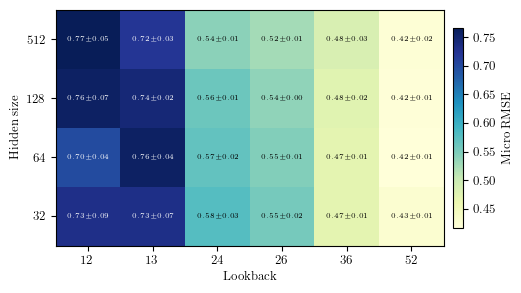

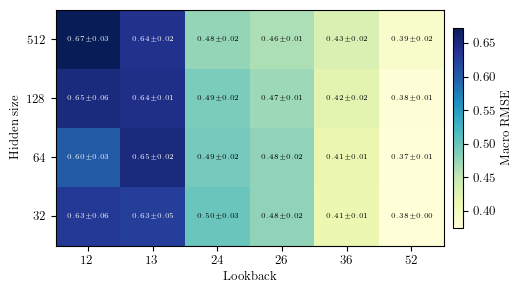

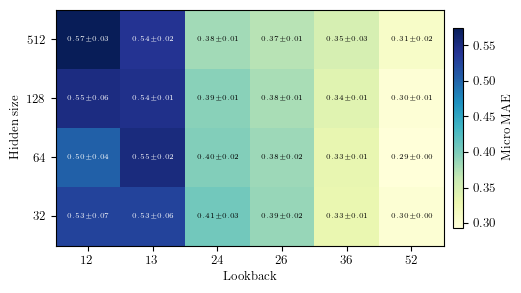

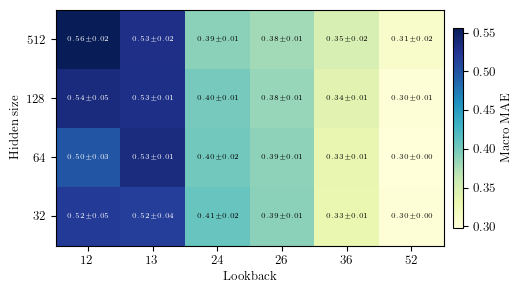

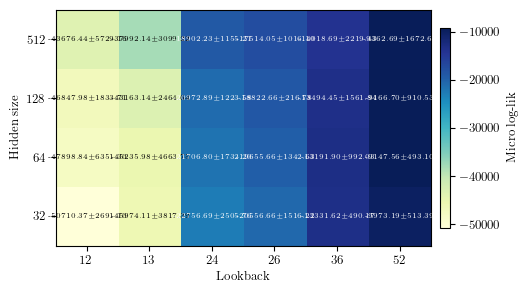

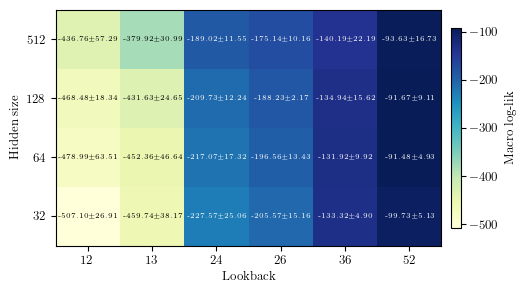

In [16]:
OUT_DIR = Path("/home/dw/cuTAGI_DW/experiments/out")
OUT_DIR.mkdir(parents=True, exist_ok=True)

VARIANT_LABELS = {"no_embeddings": r"$G_{sf/s}$"}
METRIC_LABELS = {
    "micro_rmse": "Micro RMSE",
    "macro_rmse": "Macro RMSE",
    "micro_mae": "Micro MAE",
    "macro_mae": "Macro MAE",
    "micro_log_lik": "Micro log-lik",
    "macro_log_lik": "Macro log-lik",
}


def plot_metric_heatmap(metric: str, agg: str = "mean") -> None:
    metric_col = f"{metric}_{agg}"
    std_col = f"{metric}_std"
    variants = sorted(summary["variant"].unique())
    n_variants = len(variants)

    # Peek at grid size to scale figure height
    sample = summary[summary["variant"] == variants[0]]
    n_rows = sample["hidden_size"].nunique()
    n_cols = sample["lookback"].nunique()
    fig_w = max(SINGLE_COL[0], 0.7 * n_cols * n_variants + 1.2)
    fig_h = max(2.0, 0.55 * n_rows + 0.8)

    fig, axes = plt.subplots(
        1,
        n_variants,
        figsize=(fig_w, fig_h),
        squeeze=False,
    )

    for idx, variant in enumerate(variants):
        ax = axes[0, idx]
        vdf = summary[summary["variant"] == variant]
        pivot_mean = vdf.pivot(
            index="hidden_size", columns="lookback", values=metric_col
        ).sort_index(ascending=False)
        pivot_std = vdf.pivot(
            index="hidden_size", columns="lookback", values=std_col
        ).sort_index(ascending=False)

        Z = pivot_mean.to_numpy(dtype=float)
        Z_std = np.nan_to_num(pivot_std.to_numpy(dtype=float), nan=0.0)
        has_std = np.any(Z_std > 0)

        im = ax.imshow(Z, cmap="YlGnBu", aspect="auto")

        # Annotate each cell — single line to avoid overlap
        cmap_obj = im.cmap
        norm = im.norm
        for i in range(Z.shape[0]):
            for j in range(Z.shape[1]):
                if np.isnan(Z[i, j]):
                    continue
                rgba = cmap_obj(norm(Z[i, j]))
                lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                color = "black" if lum > 0.5 else "white"
                mean_val = Z[i, j]
                if has_std:
                    txt = f"{mean_val:.2f}$\\pm${Z_std[i, j]:.2f}"
                else:
                    txt = f"{mean_val:.3f}"
                ax.text(
                    j, i, txt,
                    ha="center", va="center", fontsize=5, color=color,
                )

        ax.set_xticks(range(len(pivot_mean.columns)))
        ax.set_xticklabels(pivot_mean.columns.astype(int))
        ax.set_yticks(range(len(pivot_mean.index)))
        ax.set_yticklabels(pivot_mean.index.astype(int))
        ax.set_xlabel("Lookback")
        ax.set_ylabel("Hidden size")

        if n_variants > 1:
            label = VARIANT_LABELS.get(variant, variant)
            ax.text(
                0.5, 1.02, label,
                transform=ax.transAxes,
                ha="center", va="bottom", fontsize=9,
            )

        cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        cbar.set_label(METRIC_LABELS.get(metric, metric))

    fig.tight_layout()
    for ext in ("pgf", "pdf"):
        fig.savefig(
            OUT_DIR / f"gridsearch_{metric}.{ext}", bbox_inches="tight",
        )
    plt.show()


for metric in METRICS:
    plot_metric_heatmap(metric)
